# Лабораторная работа №7.


Разработка имитационной модели одноканальной вычислительной системы с
многоместным накопителем.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Задание №1.


Разработать компьютерную программу для имитационного моделирования
одноканальной ВС с многоместным накопителем

In [10]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz, T, m):
    processed_signals = 0
    last_start = 0
    last_end = 0
    work_times = [0] * (m + 2)
    buf = deque()
    for i in range(len(Ts)):
        while len(buf) != 0 and last_end <= Ts[i]:
            work_times[len(buf) + 1] += last_end - last_start
            last_start = last_end
            last_end += buf.popleft()
            processed_signals += 1

        if last_end <= Ts[i]:
            work_times[0] += Ts[i] - last_end
            work_times[1] += last_end - last_start
            last_start = Ts[i]
            last_end = last_start + Tz[i]
            processed_signals += 1

        elif len(buf) < m:
            work_times[len(buf) + 1] += Ts[i] - last_start
            last_start = Ts[i]
            buf.append(Tz[i])

    # Очистка буффера в конце
    while len(buf) != 0:
            work_times[len(buf) + 1] += last_end - last_start
            last_start = last_end
            last_end += buf.popleft()
            processed_signals += 1
    # Время последней заявки
    work_times[1] += last_end - last_start

    work_times[0] += max(0, T - np.sum(work_times))

    return processed_signals, work_times

def task_123(lmbd, mu, T, m):
    # Теория
    ro = lmbd / mu
    P0 = 1 / (np.sum(ro**np.arange(m + 2)))
    P1 = ro * P0
    P2 = ro**2 * P0
    P3 = ro**3 * P0
    L = P2 * 1 + P3 * 2
    print(f"Среднее число заявок в накопителе (Теор): {L}")
    # print(f"10%: [{L * 0.9}: {L * 1.1}]")

    # Симуляция
    n = 10
    means = []
    for _ in range(n):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times = simulate(T_req, T_processing, T, m)
        # print(work_times[0] / np.sum(work_times))

        acc_time = np.insert(np.arange(m + 1), 0, 0)
        mean_in_acc = sum(acc_time * work_times) / np.sum(work_times)
        means.append(mean_in_acc)
    print(f"Среднее число заявок в накопителе (Сим): {np.mean(means)}")

    means.append(np.mean(means))
    means.append(L)

    table_rows = list(range(1, 11))
    table_rows.extend(["M", "Theor"])
    df = pd.DataFrame(means, columns=["L"], index=table_rows)
    return df

Задание № 2-3.


Используя приведенные в п.7.2 формулы для СМО вычислить среднее число заявок
в накопителе для следующих исходных данных:

Сравнить с теорией

In [11]:
# Вариант 1
m1 = 2
lmbd1 = 0.5
mu1 = 0.4
T = 1000

df = task_123(lmbd1, mu1, T, m1)
print(df)

Среднее число заявок в накопителе (Теор): 0.948509485094851
Среднее число заявок в накопителе (Сим): 0.9465400129147092
              L
1      0.895336
2      0.927711
3      0.978299
4      1.007972
5      0.825169
6      0.969984
7      0.909070
8      1.035135
9      0.947504
10     0.969220
M      0.946540
Theor  0.948509


In [12]:
# Вариант 2
m2 = 2
lmbd2 = 1
mu2 = 0.4
T = 1000

task_123(lmbd2, mu2, T, m2)

Среднее число заявок в накопителе (Теор): 1.477832512315271
Среднее число заявок в накопителе (Сим): 1.47266439038181


,L
1,1.397845
2,1.464914
3,1.524482
4,1.475570
5,1.481544
6,1.455277
7,1.488694
8,1.465066
9,1.461260
10,1.511993


In [13]:
# Вариант 3
m1 = 2
lmbd1 = 4
mu1 = 0.4
T = 1000

task_123(lmbd1, mu1, T, m1)

Среднее число заявок в накопителе (Теор): 1.8901890189018902
Среднее число заявок в накопителе (Сим): 1.8886208606254324


,L
1,1.887068
2,1.895215
3,1.881676
4,1.894849
5,1.892507
6,1.891853
7,1.886720
8,1.873341
9,1.886036
10,1.896944


Задание №4.


На основе разработанной имитационной модели ИС с многоместным накопителем провести исследование зависимостей выходных характеристик ИС при возрастании нагрузки системы и возможности ее компенсации с увеличением числа мест в накопителе.
В качестве выходных характеристик для анализа использовать следующие:

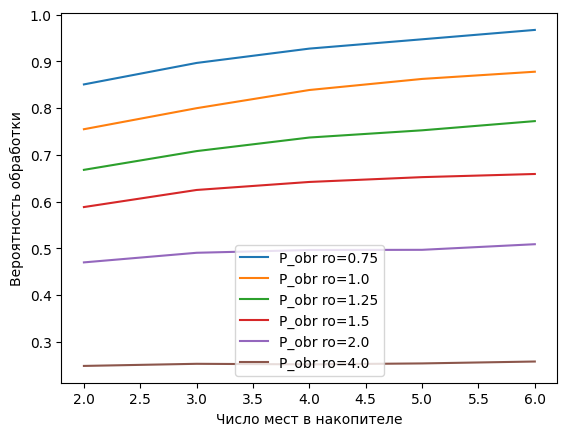

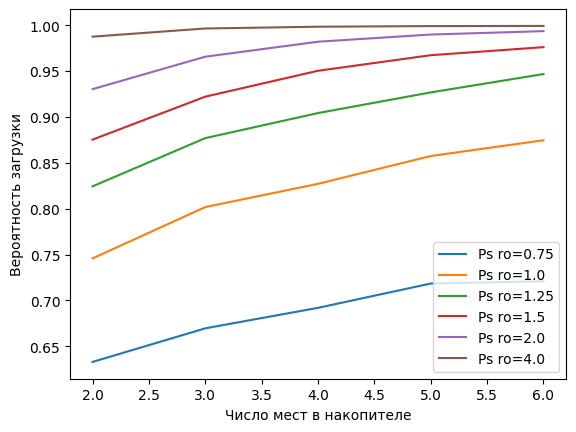

In [14]:
mu4 = 0.4
T = 1000
ros = [0.75, 1.0, 1.25, 1.5, 2.0, 4.0]
ms = range(2, 7)

all_ps = [[] for _ in range(len(ros))]
all_pw = [[] for _ in range(len(ros))]

for m in ms:
    for ro_idx in range(len(ros)):
        ro = ros[ro_idx]
        lmbd = ro * mu4

        n = 100
        pss = []
        pws = []
        for _ in range(n):
            T_req = generate_request_time_exp(lmbd, T)
            T_processing = generate_process_time_exp(mu4, len(T_req))
            processed_signals, work_times = simulate(T_req, T_processing, T, m)
            pss.append(processed_signals / len(T_req))
            pws.append(np.sum(work_times[1:]) / np.sum(work_times))
        all_ps[ro_idx].append(np.mean(pss))
        all_pw[ro_idx].append(np.mean(pws))

for i in range(len(ros)):
    plt.plot(ms, all_ps[i], label=f'P_obr ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.show()

for i in range(len(ros)):
    plt.plot(ms, all_pw[i], label=f'Ps ro={ros[i]}')
plt.xlabel("Число мест в накопителе")
plt.ylabel("Вероятность загрузки")
plt.legend()
plt.show()